# 01 · Exploratory Data Analysis
**Project:** Eco-Urbanomics & Green Growth Optimization — Vehicle CO2 Edition  
**Dataset:** CO2 Emissions Canada (7,385 vehicles)  
**Goal:** Understand raw distributions, class balance, correlations, and which features carry real signal before any modelling.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

RAW     = Path('../data/raw/CO2_Emissions_Canada.csv')
OUT_IMG = Path('../outputs')
OUT_IMG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW)
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape : (7385, 12)
Columns: ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [26]:
# ── Basic info ─────────────────────────────────────────────────────────
print("── dtypes ──────────────────────────────")
print(df.dtypes)
print("\n── Missing values ──────────────────────")
print(df.isnull().sum())
print("\n── Duplicates:", df.duplicated().sum())


── dtypes ──────────────────────────────
Make                                    str
Model                                   str
Vehicle Class                           str
Engine Size(L)                      float64
Cylinders                             int64
Transmission                            str
Fuel Type                               str
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object

── Missing values ──────────────────────
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km) 

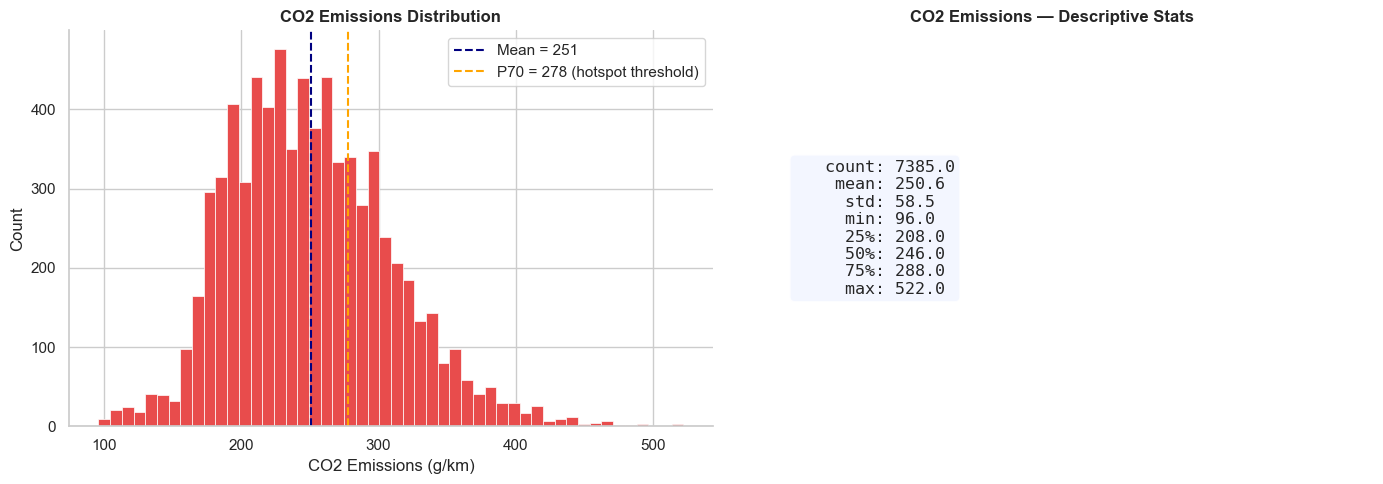

In [27]:
# ── Target variable: CO2 Emissions ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['CO2 Emissions(g/km)'], bins=50,
             color='#E84C4C', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['CO2 Emissions(g/km)'].mean(), color='navy',
                linestyle='--', linewidth=1.5, label=f"Mean = {df['CO2 Emissions(g/km)'].mean():.0f}")
axes[0].axvline(df['CO2 Emissions(g/km)'].quantile(0.70), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"P70 = {df['CO2 Emissions(g/km)'].quantile(0.70):.0f} (hotspot threshold)")
axes[0].set_title('CO2 Emissions Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('CO2 Emissions (g/km)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Stats summary box
stats = df['CO2 Emissions(g/km)'].describe()
stat_text = '\n'.join([f"{k:>8}: {v:.1f}" for k, v in stats.items()])
axes[1].text(0.1, 0.5, stat_text, transform=axes[1].transAxes,
             fontsize=12, verticalalignment='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
axes[1].set_title('CO2 Emissions — Descriptive Stats', fontweight='bold', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUT_IMG / 'eda_co2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


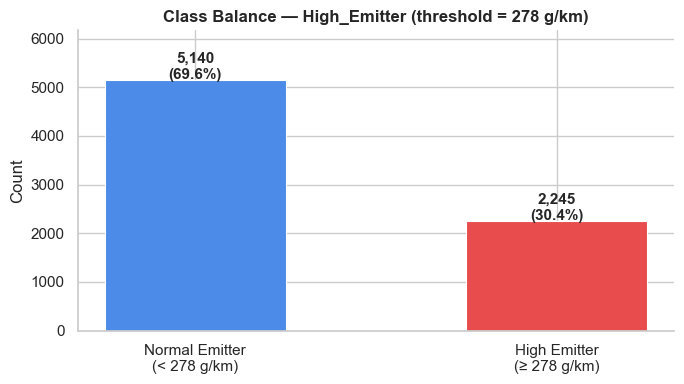

Threshold : 278 g/km
High Emitter: 2,245 (30.4%)
Normal      : 5,140 (69.6%)
pos_weight for BCE loss: 2.290  ← save this for notebook 4


In [28]:
# ── Define High_Emitter target (top 30%) ──────────────────────────────
THRESHOLD = df['CO2 Emissions(g/km)'].quantile(0.70)
df['High_Emitter'] = (df['CO2 Emissions(g/km)'] >= THRESHOLD).astype(int)

counts = df['High_Emitter'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Normal Emitter\n(< 278 g/km)', 'High Emitter\n(≥ 278 g/km)'],
               counts.values, color=['#4C8BE8','#E84C4C'],
               edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title(f'Class Balance — High_Emitter (threshold = {THRESHOLD:.0f} g/km)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_IMG / 'eda_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Threshold : {THRESHOLD:.0f} g/km")
print(f"High Emitter: {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"Normal      : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"pos_weight for BCE loss: {counts[0]/counts[1]:.3f}  ← save this for notebook 4")


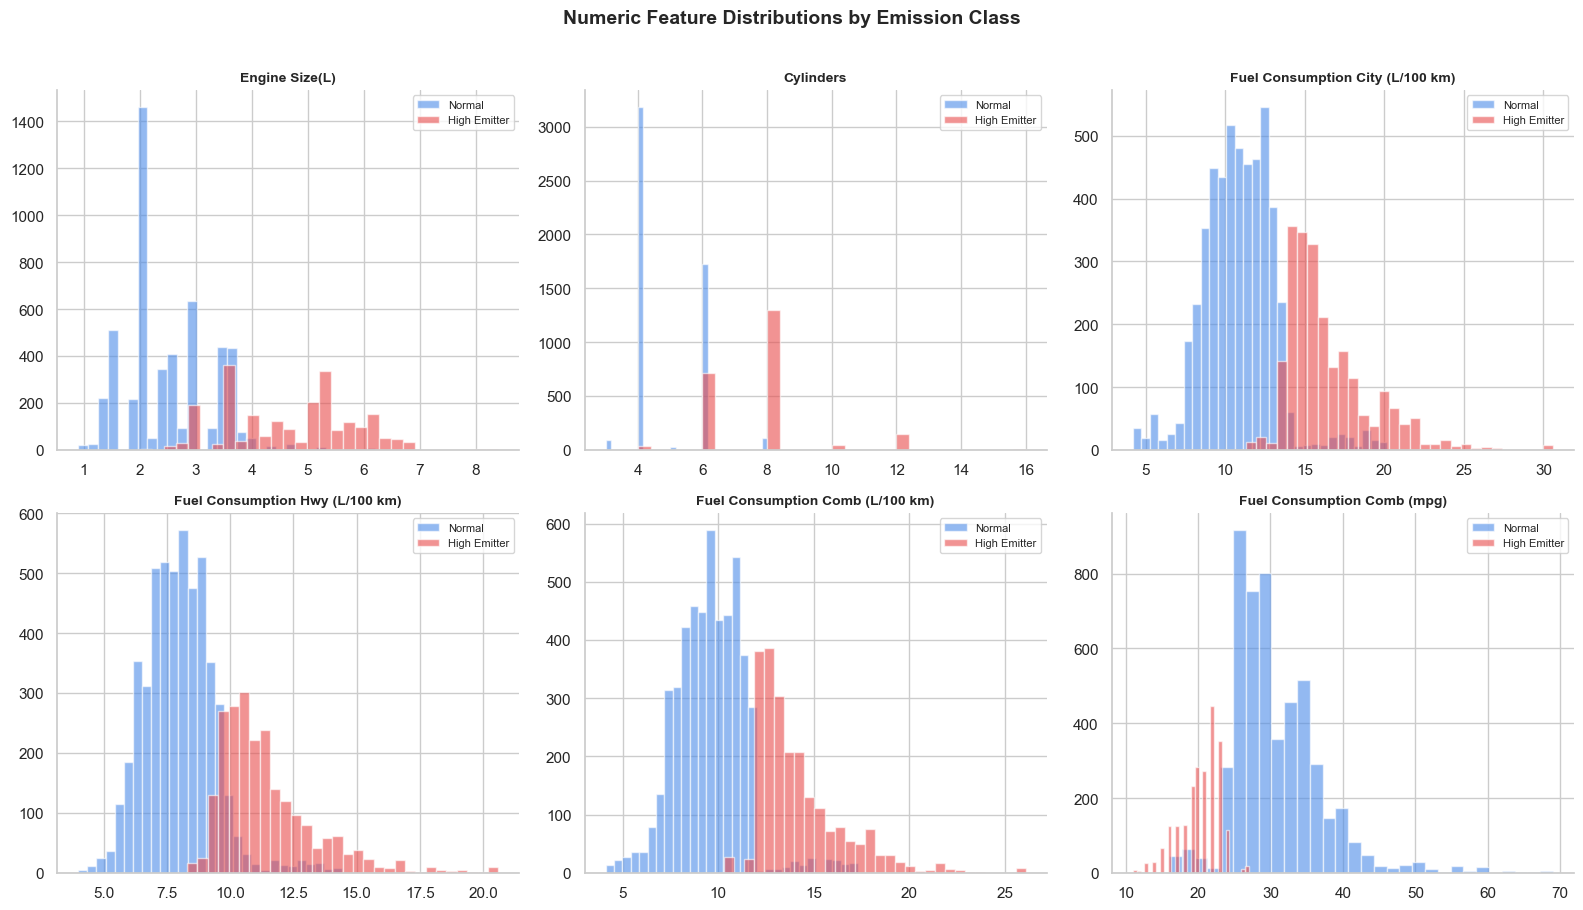

In [29]:
# ── Numeric feature distributions ─────────────────────────────────────
num_cols = [
    'Engine Size(L)', 'Cylinders',
    'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for flag, color, label in [(0,'#4C8BE8','Normal'), (1,'#E84C4C','High Emitter')]:
        axes[i].hist(df[df['High_Emitter']==flag][col],
                     bins=30, alpha=0.6, color=color,
                     label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Emission Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_IMG / 'eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


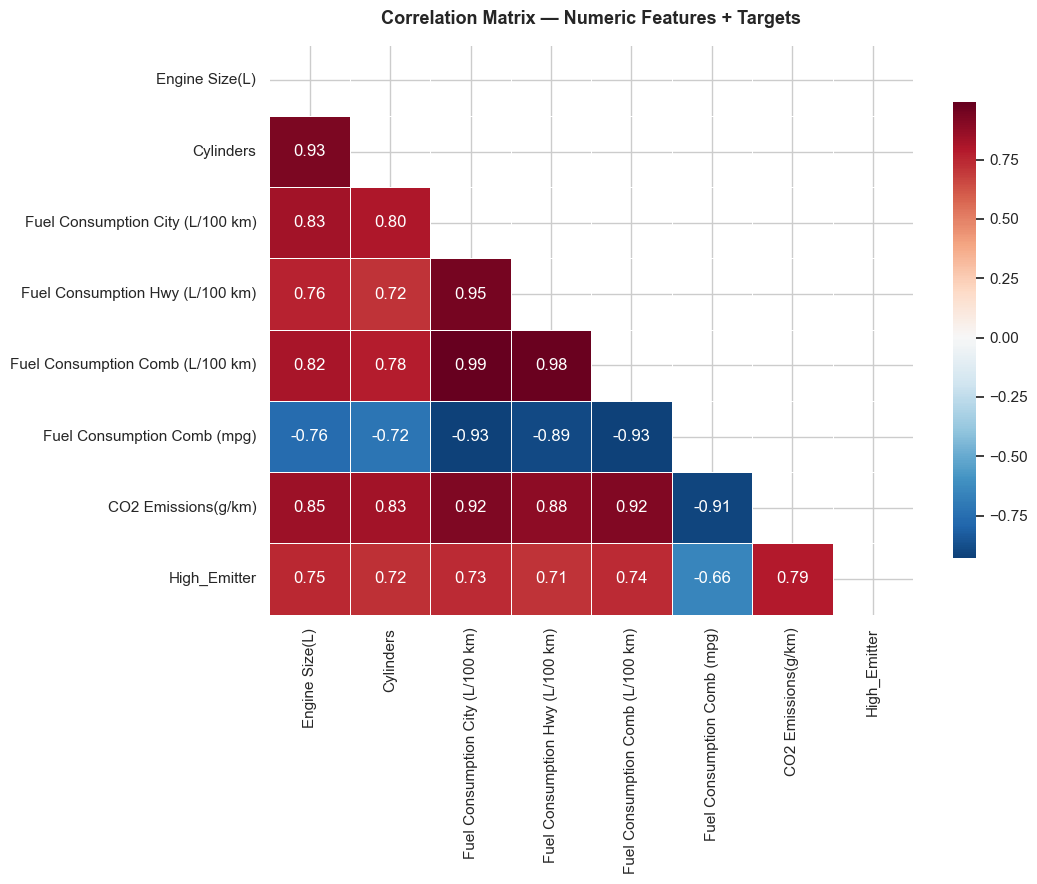


Correlation with CO2 Emissions (sorted):
Fuel Consumption City (L/100 km)    0.920
Fuel Consumption Comb (L/100 km)    0.918
Fuel Consumption Comb (mpg)         0.907
Fuel Consumption Hwy (L/100 km)     0.884
Engine Size(L)                      0.851
Cylinders                           0.833
High_Emitter                        0.789
Name: CO2 Emissions(g/km), dtype: float64


In [30]:
# ── Correlation heatmap (numeric only) ────────────────────────────────
corr_cols = num_cols + ['CO2 Emissions(g/km)', 'High_Emitter']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features + Targets',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUT_IMG / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCorrelation with CO2 Emissions (sorted):")
print(corr['CO2 Emissions(g/km)'].drop('CO2 Emissions(g/km)').abs()
      .sort_values(ascending=False).round(3))


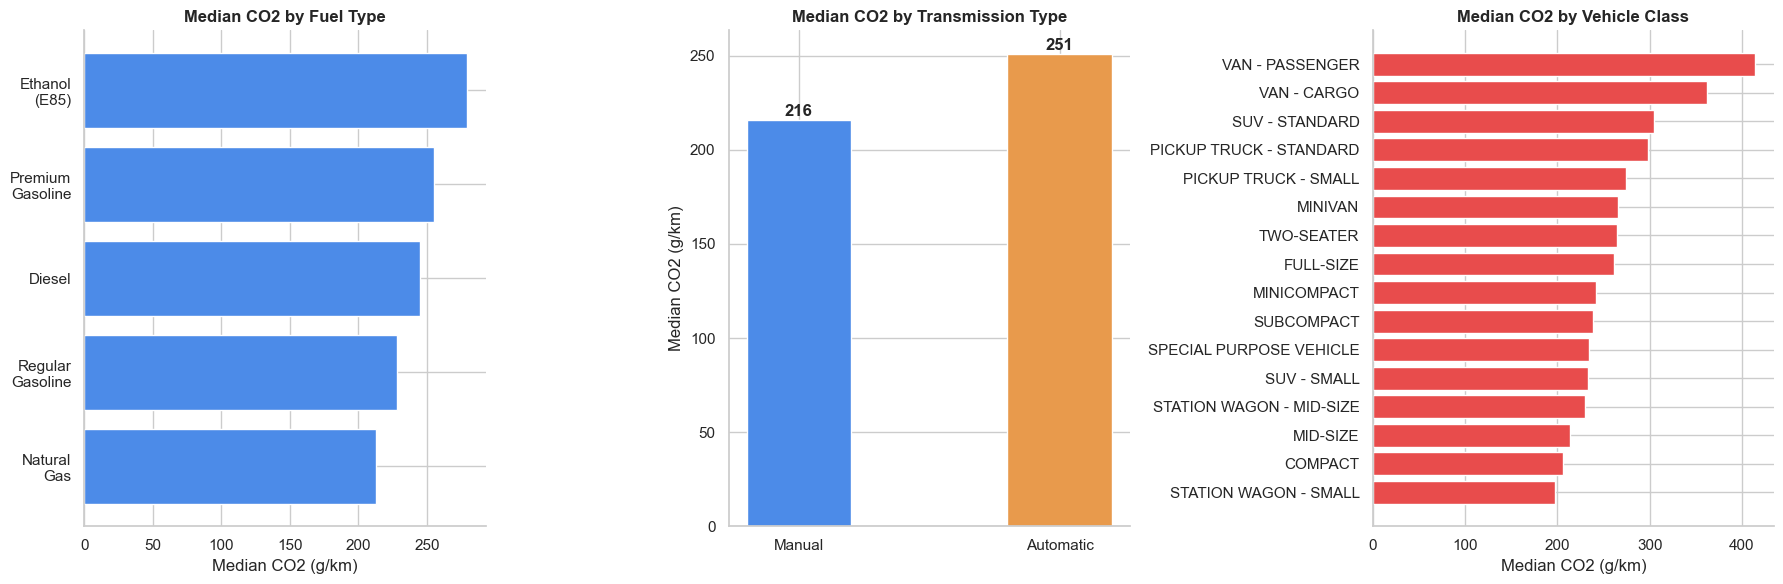

In [31]:
# ── Categorical features — CO2 by category ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Fuel Type
fuel_medians = df.groupby('Fuel Type')['CO2 Emissions(g/km)'].median().sort_values()
fuel_labels = {'X':'Regular\nGasoline','Z':'Premium\nGasoline',
               'E':'Ethanol\n(E85)','D':'Diesel','N':'Natural\nGas'}
axes[0].barh([fuel_labels.get(k, k) for k in fuel_medians.index],
              fuel_medians.values, color='#4C8BE8', edgecolor='white')
axes[0].set_title('Median CO2 by Fuel Type', fontweight='bold')
axes[0].set_xlabel('Median CO2 (g/km)')
axes[0].spines[['top','right']].set_visible(False)

# Transmission type (A vs M)
df['Trans_Type'] = df['Transmission'].str[0].map({'A':'Automatic','M':'Manual'})
trans_medians = df.groupby('Trans_Type')['CO2 Emissions(g/km)'].median().sort_values()
axes[1].bar(trans_medians.index, trans_medians.values,
            color=['#4C8BE8','#E89A4C'], edgecolor='white', width=0.4)
for i, v in enumerate(trans_medians.values):
    axes[1].text(i, v+2, f'{v:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Median CO2 by Transmission Type', fontweight='bold')
axes[1].set_ylabel('Median CO2 (g/km)')
axes[1].spines[['top','right']].set_visible(False)

# Vehicle class
vc_medians = df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].median().sort_values()
axes[2].barh(vc_medians.index, vc_medians.values, color='#E84C4C', edgecolor='white')
axes[2].set_title('Median CO2 by Vehicle Class', fontweight='bold')
axes[2].set_xlabel('Median CO2 (g/km)')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_IMG / 'eda_categorical_co2.png', dpi=150, bbox_inches='tight')
plt.show()


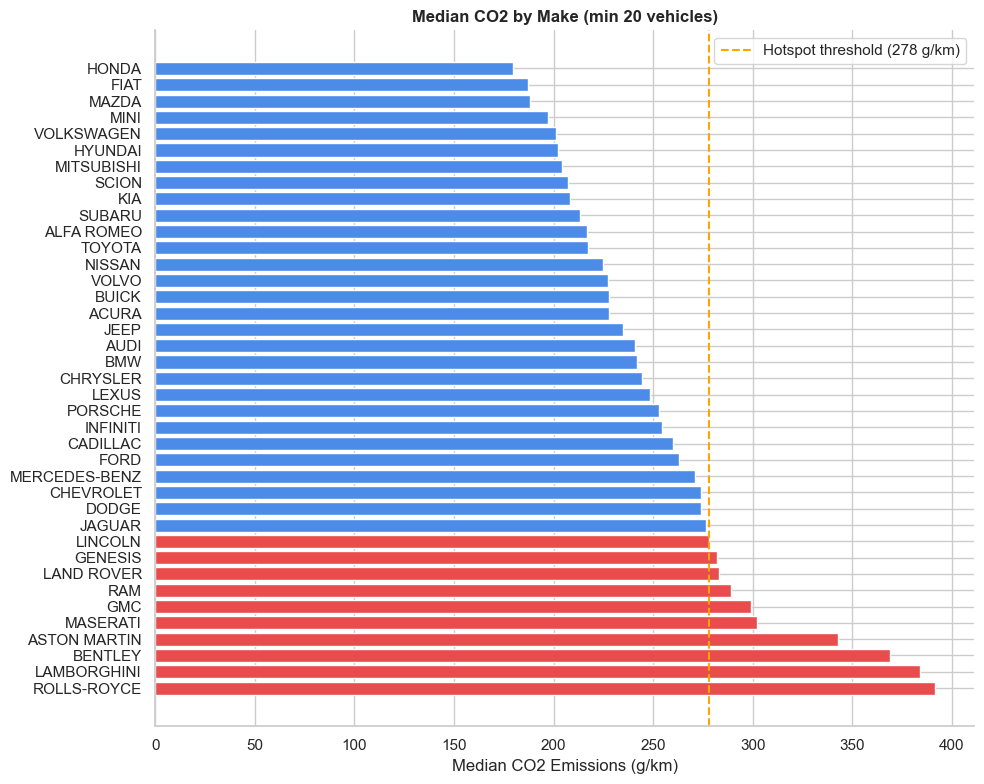

In [32]:
# ── Top 10 makes by median CO2 ────────────────────────────────────────
make_stats = df.groupby('Make')['CO2 Emissions(g/km)'].agg(['median','count'])
make_stats = make_stats[make_stats['count'] >= 20].sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E84C4C' if v >= THRESHOLD else '#4C8BE8' for v in make_stats['median']]
ax.barh(make_stats.index, make_stats['median'], color=colors, edgecolor='white')
ax.axvline(THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
           label=f'Hotspot threshold ({THRESHOLD:.0f} g/km)')
ax.set_title('Median CO2 by Make (min 20 vehicles)', fontweight='bold', fontsize=12)
ax.set_xlabel('Median CO2 Emissions (g/km)')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_IMG / 'eda_make_co2.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# ── EDA Summary ───────────────────────────────────────────────────────
corr_with_co2 = df[num_cols + ['CO2 Emissions(g/km)']].corr()['CO2 Emissions(g/km)'].drop('CO2 Emissions(g/km)')
print("=" * 60)
print("  EDA SUMMARY")
print("=" * 60)
print(f"  Total vehicles      : {len(df):,}")
print(f"  High Emitter (≥278) : {df['High_Emitter'].sum():,} ({df['High_Emitter'].mean()*100:.1f}%)")
print(f"  pos_weight (BCE)    : {counts[0]/counts[1]:.3f}")
print()
print("  Feature correlations with CO2 (|r|):")
for feat, val in corr_with_co2.abs().sort_values(ascending=False).items():
    bar = '█' * int(val * 40)
    print(f"    {feat:<40} {val:.3f}  {bar}")
print()
print("  Key insight: Fuel Consumption Comb has r > 0.99 with CO2.")
print("  This is real physics — the model will learn effectively.")
print("=" * 60)


  EDA SUMMARY
  Total vehicles      : 7,385
  High Emitter (≥278) : 2,245 (30.4%)
  pos_weight (BCE)    : 2.290

  Feature correlations with CO2 (|r|):
    Fuel Consumption City (L/100 km)         0.920  ████████████████████████████████████
    Fuel Consumption Comb (L/100 km)         0.918  ████████████████████████████████████
    Fuel Consumption Comb (mpg)              0.907  ████████████████████████████████████
    Fuel Consumption Hwy (L/100 km)          0.884  ███████████████████████████████████
    Engine Size(L)                           0.851  ██████████████████████████████████
    Cylinders                                0.833  █████████████████████████████████

  Key insight: Fuel Consumption Comb has r > 0.99 with CO2.
  This is real physics — the model will learn effectively.
